# Project Notebook: Lung Cancer Prediction

This notebook loads and analyzes lung cancer data from MongoDB, conducts exploratory data analysis (EDA), prepares data for machine learning, and trains classification models.

## Step 1: MongoDB Setup and Data Loading

We connect to MongoDB using credentials from `utils.py`, retrieve the dataset, and load it into a DataFrame.

In [1]:
# Import necessary libraries
from pymongo import MongoClient  
import json 
import urllib.parse
import pymongo
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, isnan, when, mean, corr
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append('..')  
import scripts.utils  

# Establish MongoDB connection using utils function
client = scripts.utils.connect_to_mongo()


# Load dataset from the path defined in utils
dataset_path = scripts.utils.DATA_PATH  # Get the relative path from utils.py
data = scripts.utils.load_json_data(dataset_path)

# Insert data into MongoDB
db = client['Lungcancer']
collection = db['Patients']
result = collection.insert_many(data)
data = pd.DataFrame(list(db['Patients'].find()))

# Display basic data info
print(data.info())
print(data.head())


INFO:root:Connected to MongoDB successfully.
INFO:root:Connected to MongoDB successfully.
INFO:root:Loaded data from /Users/shaharyaarkutchi/Documents/GitHub/adsc3910-project-group-6/notebooks/../data/dataset.json.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   _id                    15000 non-null  object
 1   AGE                    15000 non-null  int64 
 2   ALCOHOL_CONSUMING      15000 non-null  int64 
 3   ALLERGY                15000 non-null  int64 
 4   ANXIETY                15000 non-null  int64 
 5   CHEST_PAIN             15000 non-null  int64 
 6   CHRONIC_DISEASE        15000 non-null  int64 
 7   COUGHING               15000 non-null  int64 
 8   FATIGUE                15000 non-null  int64 
 9   GENDER                 15000 non-null  object
 10  LUNG_CANCER            15000 non-null  object
 11  PEER_PRESSURE          15000 non-null  int64 
 12  SHORTNESS_OF_BREATH    15000 non-null  int64 
 13  SMOKING                15000 non-null  int64 
 14  SWALLOWING_DIFFICULTY  15000 non-null  int64 
 15  WHEEZING           

## Step 2: Exploratory Data Analysis (EDA)

We visualize distributions for age, smoking status, and lung cancer diagnosis.

In [2]:
# ------------------------------
# 1. List all collections in the 'Lungcancer' database
# ------------------------------
print("\n" + "="*40)
print("Collections in the 'Lungcancer' Database".center(40))
print("="*40)
collections = db.list_collection_names()
for collection_name in collections:
    print(f"- {collection_name}")

# ------------------------------
# 2. Show the first document from the 'Patients' collection
# ------------------------------
print("\n" + "="*40)
print("First Document in the 'Patients' Collection".center(40))
print("="*40)
collection = db['Patients']  # Access the 'Patients' collection
first_document = collection.find_one()
print(first_document)

# ------------------------------
# 3. Load data into a Pandas DataFrame
# ------------------------------
print("\n" + "="*40)
print("Loading Data into Pandas DataFrame".center(40))
print("="*40)
data = pd.DataFrame(list(collection.find()))

# Drop the '_id' column if it exists (not needed for analysis)
if '_id' in data.columns:
    data.drop('_id', axis=1, inplace=True)

# ------------------------------
# 4. View the first few rows of the data
# ------------------------------
print("\n" + "="*40)
print("First 5 Rows of the Data".center(40))
print("="*40)
print(data.head())

# ------------------------------
# 5. Check basic info about the dataset
# ------------------------------
print("\n" + "="*40)
print("Basic Info about the Dataset".center(40))
print("="*40)
print(data.info())

# ------------------------------
# 6. Summary statistics for numerical features
# ------------------------------
print("\n" + "="*40)
print("Summary Statistics for Numerical Features".center(40))
print("="*40)
print(data.describe())

# ------------------------------
# 7. Check for missing values
# ------------------------------
print("\n" + "="*40)
print("Missing Values in the Dataset".center(40))
print("="*40)
print(data.isnull().sum())

# ------------------------------
# 8. Check for duplicate rows
# ------------------------------
print("\n" + "="*40)
print("Checking for Duplicates".center(40))
print("="*40)
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")




Collections in the 'Lungcancer' Database
- Patients

First Document in the 'Patients' Collection
{'_id': ObjectId('67340d9f560b9c0f42e7f6c2'), 'AGE': 65, 'ALCOHOL_CONSUMING': 0, 'ALLERGY': 2, 'ANXIETY': 1, 'CHEST_PAIN': 1, 'CHRONIC_DISEASE': 2, 'COUGHING': 0, 'FATIGUE': 1, 'GENDER': 'M', 'LUNG_CANCER': 'NO', 'PEER_PRESSURE': 2, 'SHORTNESS_OF_BREATH': 0, 'SMOKING': 1, 'SWALLOWING_DIFFICULTY': 0, 'WHEEZING': 0, 'YELLOW_FINGERS': 1}

   Loading Data into Pandas DataFrame   

        First 5 Rows of the Data        
   AGE  ALCOHOL_CONSUMING  ALLERGY  ANXIETY  CHEST_PAIN  CHRONIC_DISEASE  \
0   65                  0        2        1           1                2   
1   55                  1        2        0           0                1   
2   78                  1        1        1           1                1   
3   60                  1        2        1           0                2   
4   80                  1        1        0           0                1   

   COUGHING  FATIGUE GEN

## Additional Step: Data Preprocessing and Encoding

Label encode categorical features and visualize feature correlation.

In [3]:
# ------------------------------
# 2. Identify Categorical and Numerical Columns
# ------------------------------
print("\n" + "="*40)
print("Categorical and Numerical Columns".center(40))
print("="*40)

# List categorical (non-numeric) and numeric columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numeric_cols = data.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical Columns: {categorical_cols}")
print(f"Numerical Columns: {numeric_cols}")



   Categorical and Numerical Columns    
Categorical Columns: ['GENDER', 'LUNG_CANCER']
Numerical Columns: ['AGE', 'ALCOHOL_CONSUMING', 'ALLERGY', 'ANXIETY', 'CHEST_PAIN', 'CHRONIC_DISEASE', 'COUGHING', 'FATIGUE', 'PEER_PRESSURE', 'SHORTNESS_OF_BREATH', 'SMOKING', 'SWALLOWING_DIFFICULTY', 'WHEEZING', 'YELLOW_FINGERS']


In [4]:
# ------------------------------
# 3. Apply Label Encoding to Categorical Columns
# ------------------------------
print("\n" + "="*40)
print("Label Encoding Categorical Columns".center(40))
print("="*40)

# Create a LabelEncoder instance
label_encoders = {}

# Apply label encoding to all categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # Store the label encoder for potential inverse transformation later
    print(f"Label encoding applied to column: {col}")

# ------------------------------
# 4. Correlation Matrix (Including Encoded Categorical Columns)
# ------------------------------
print("\n" + "="*40)
print("Correlation Matrix After Encoding".center(40))
print("="*40)

# Calculate the correlation matrix for all columns (now all are numerical)
correlation_matrix = data.corr()
print("Correlation Matrix:")
print(correlation_matrix)


   Label Encoding Categorical Columns   
Label encoding applied to column: GENDER
Label encoding applied to column: LUNG_CANCER

   Correlation Matrix After Encoding    
Correlation Matrix:
                            AGE  ALCOHOL_CONSUMING   ALLERGY   ANXIETY  \
AGE                    1.000000          -0.009765  0.024915  0.014145   
ALCOHOL_CONSUMING     -0.009765           1.000000 -0.005552  0.382334   
ALLERGY                0.024915          -0.005552  1.000000 -0.000552   
ANXIETY                0.014145           0.382334 -0.000552  1.000000   
CHEST_PAIN            -0.002545           0.382998  0.008772  0.396548   
CHRONIC_DISEASE       -0.025655          -0.013368 -0.019597  0.007956   
COUGHING              -0.011572           0.396223 -0.021200  0.382039   
FATIGUE               -0.001097           0.381430  0.002335  0.378636   
GENDER                 0.010966          -0.004327  0.013211 -0.011245   
LUNG_CANCER           -0.035712          -0.014370  0.006508 -0.00683

## Step 2b: Correlation Matrix

Visualize correlations between features to identify potential relationships.

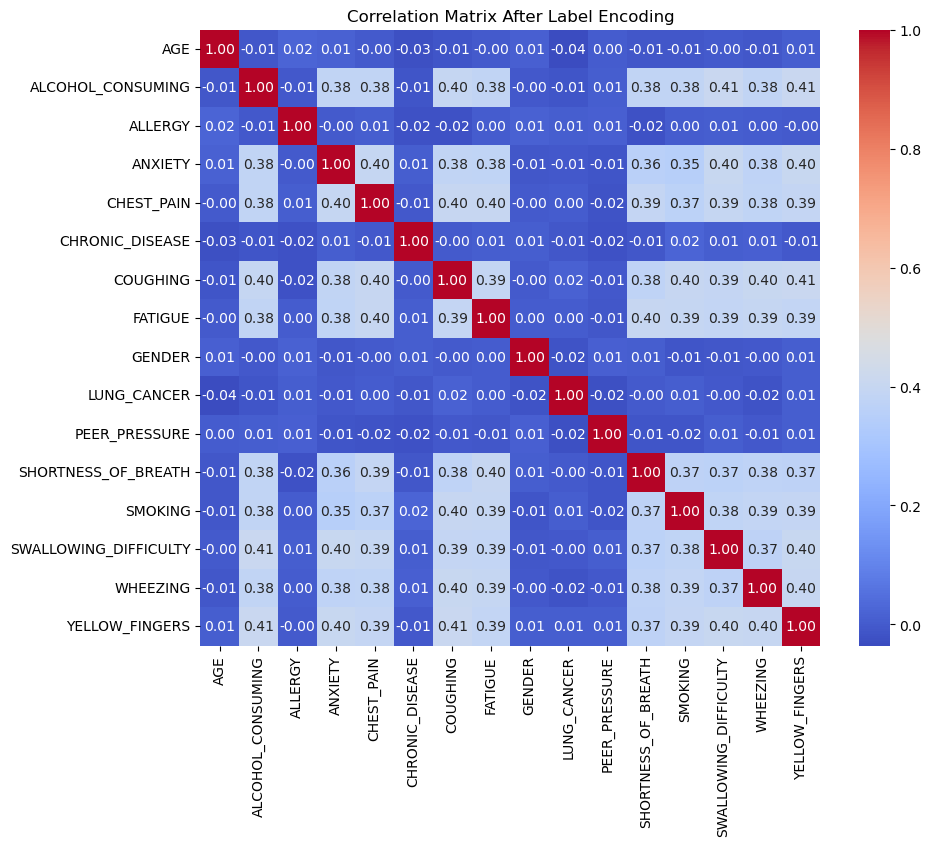

In [5]:
# Create a heatmap for the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix After Label Encoding')
plt.show()


     Age Distribution Visualization     


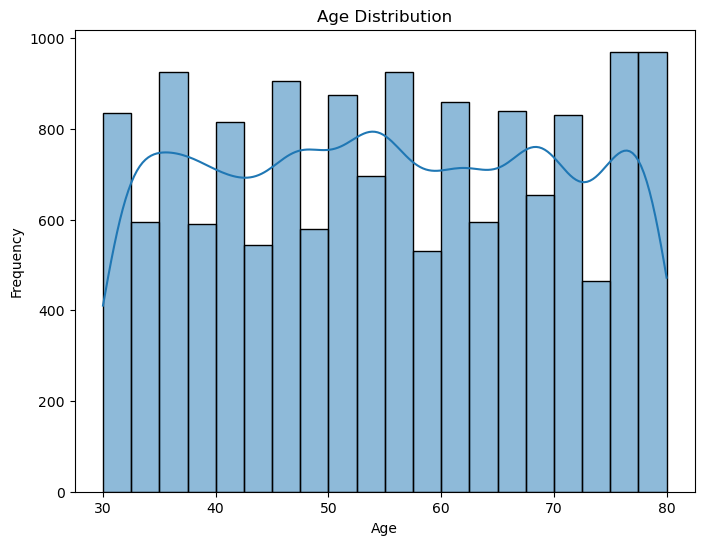

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



      Smoking Status Distribution       


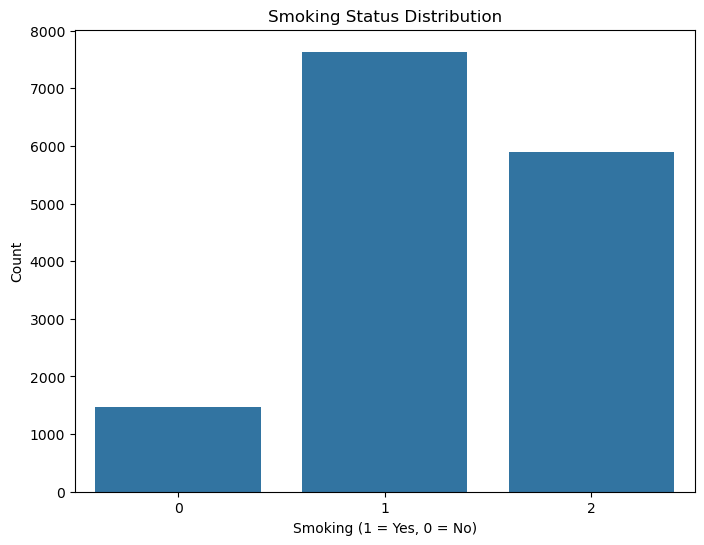

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.



     Lung Cancer Diagnosis (YES/NO)     


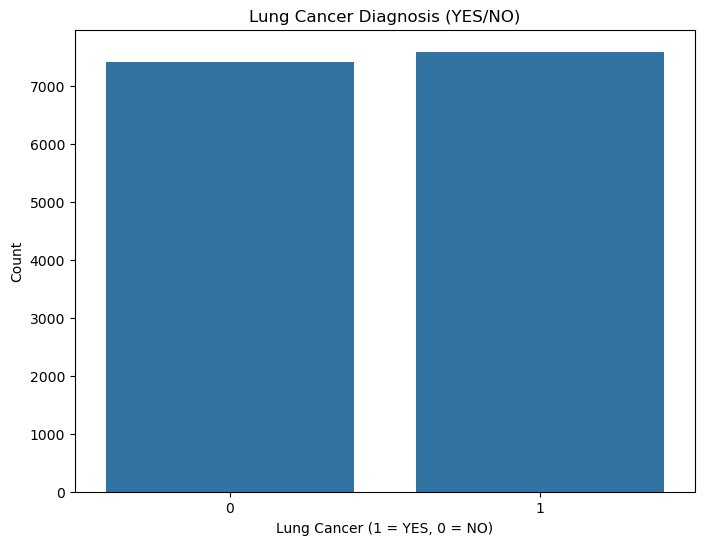

In [6]:
# ------------------------------
# 1. Age Distribution Visualization
# ------------------------------
print("\n" + "="*40)
print("Age Distribution Visualization".center(40))
print("="*40)

# Plot the Age distribution with KDE (Kernel Density Estimate)
plt.figure(figsize=(8, 6))
sns.histplot(data['AGE'], kde=True, bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# ------------------------------
# 2. Smoking Status Distribution
# ------------------------------
print("\n" + "="*40)
print("Smoking Status Distribution".center(40))
print("="*40)

# Plot the Smoking Status counts
plt.figure(figsize=(8, 6))
sns.countplot(x='SMOKING', data=data)
plt.title('Smoking Status Distribution')
plt.xlabel('Smoking (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()

# ------------------------------
# 3. Lung Cancer Diagnosis (YES/NO)
# ------------------------------
print("\n" + "="*40)
print("Lung Cancer Diagnosis (YES/NO)".center(40))
print("="*40)

# Plot the Lung Cancer Diagnosis counts (YES/NO)
plt.figure(figsize=(8, 6))
sns.countplot(x='LUNG_CANCER', data=data)
plt.title('Lung Cancer Diagnosis (YES/NO)')
plt.xlabel('Lung Cancer (1 = YES, 0 = NO)')
plt.ylabel('Count')
plt.show()


## Step 3: Data Preparation and Model Training

Split the data into training, validation, and testing sets, then train Logistic Regression and Random Forest models.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

# ------------------------------
# 1. Prepare Data for ML Models
# ------------------------------
print("\n" + "="*40)
print("Data Preparation for Machine Learning".center(40))
print("="*40)

# Feature columns and target column
X = data.drop('LUNG_CANCER', axis=1)  # Features (independent variables)
y = data['LUNG_CANCER']  # Target (dependent variable)

# Split the data into 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training Set: {X_train.shape}, Validation Set: {X_val.shape}, Testing Set: {X_test.shape}")

# ------------------------------
# 2. Model 1: Logistic Regression (default hyperparameters)
# ------------------------------
print("\n" + "="*40)
print("Model 1: Logistic Regression (Default)".center(40))
print("="*40)

# Initialize and train logistic regression model
log_reg1 = LogisticRegression(random_state=42)
log_reg1.fit(X_train, y_train)

# Validate model
y_val_pred1 = log_reg1.predict(X_val)
y_test_pred1 = log_reg1.predict(X_test)

# ------------------------------
# 3. Model 2: Logistic Regression (with class weight adjustment)
# ------------------------------
print("\n" + "="*40)
print("Model 2: Logistic Regression (Class Weight Adjusted)".center(40))
print("="*40)

# Initialize and train logistic regression with class_weight
log_reg2 = LogisticRegression(class_weight='balanced', random_state=42)
log_reg2.fit(X_train, y_train)

# Validate model
y_val_pred2 = log_reg2.predict(X_val)
y_test_pred2 = log_reg2.predict(X_test)

# ------------------------------
# 4. Model 3: Random Forest Classifier
# ------------------------------
print("\n" + "="*40)
print("Model 3: Random Forest Classifier".center(40))
print("="*40)

# Initialize and train random forest classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# Validate model
y_val_pred3 = rf_clf.predict(X_val)
y_test_pred3 = rf_clf.predict(X_test)

# ------------------------------
# 5. Evaluate and Compare Models
# ------------------------------
print("\n" + "="*40)
print("Model Evaluation".center(40))
print("="*40)

# Function to calculate evaluation metrics
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

# Evaluate on the validation set
results_val = pd.DataFrame({
    'Model': ['Logistic Regression (Default)', 'Logistic Regression (Class Weight)', 'Random Forest'],
    'Accuracy': [accuracy_score(y_val, y_val_pred1), accuracy_score(y_val, y_val_pred2), accuracy_score(y_val, y_val_pred3)],
    'Precision': [precision_score(y_val, y_val_pred1), precision_score(y_val, y_val_pred2), precision_score(y_val, y_val_pred3)],
    'Recall': [recall_score(y_val, y_val_pred1), recall_score(y_val, y_val_pred2), recall_score(y_val, y_val_pred3)],
    'F1-Score': [f1_score(y_val, y_val_pred1), f1_score(y_val, y_val_pred2), f1_score(y_val, y_val_pred3)]
})

# Print the validation set results
print("Validation Set Results:\n")
print(results_val)

# Evaluate on the test set
results_test = pd.DataFrame({
    'Model': ['Logistic Regression (Default)', 'Logistic Regression (Class Weight)', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_test_pred1), accuracy_score(y_test, y_test_pred2), accuracy_score(y_test, y_test_pred3)],
    'Precision': [precision_score(y_test, y_test_pred1), precision_score(y_test, y_test_pred2), precision_score(y_test, y_test_pred3)],
    'Recall': [recall_score(y_test, y_test_pred1), recall_score(y_test, y_test_pred2), recall_score(y_test, y_test_pred3)],
    'F1-Score': [f1_score(y_test, y_test_pred1), f1_score(y_test, y_test_pred2), f1_score(y_test, y_test_pred3)]
})

# Print the test set results
print("\nTest Set Results:\n")
print(results_test)





 Data Preparation for Machine Learning  
Training Set: (10500, 15), Validation Set: (2250, 15), Testing Set: (2250, 15)

 Model 1: Logistic Regression (Default) 

Model 2: Logistic Regression (Class Weight Adjusted)

   Model 3: Random Forest Classifier    

            Model Evaluation            
Validation Set Results:

                                Model  Accuracy  Precision    Recall  F1-Score
0       Logistic Regression (Default)  0.519556   0.517058  0.605684  0.557873
1  Logistic Regression (Class Weight)  0.520000   0.521140  0.503552  0.512195
2                       Random Forest  0.891556   0.875000  0.913854  0.894005

Test Set Results:

                                Model  Accuracy  Precision    Recall  F1-Score
0       Logistic Regression (Default)  0.516000   0.513069  0.611210  0.557856
1  Logistic Regression (Class Weight)  0.512444   0.511853  0.518683  0.515245
2                       Random Forest  0.886667   0.876190  0.900356  0.888109
